# **GEOG5302 Assessment 2: Data Science Mini Project**

# **Introduction**

Agricultural land use is widely recognised as one of the major contributors to diffuse water pollution, particularly through the runoff of nutrients such as nitrates into surface water systems. In the United Kingdom, intensive agricultural practices, including the application of synthetic fertilisers and manure, have been linked to elevated nitrate concentrations in rivers and streams. Elevated nitrate levels pose significant risks to aquatic ecosystems, drinking water quality, and human health, making nutrient pollution a major concern for environmental management and policy in the UK. Against this context, this study aims to investigate the relationship between agricultural land use and nitrate concentrations in surface waters across the United Kingdom using national-scale environmental datasets. This project applies data science techniques to explore spatial patterns in water quality and assess whether agricultural land use intensity is associated with higher nitrate concentrations. The remainder of this notebook introduces the datasets used, outlines the data processing and exploratory analysis, applies regression and comparative statistical methods, and discusses the implications of the findings within a UK environmental data science context.

# **Background and Literature**

Previous studies have demonstrated that excessive nitrate inputs from agricultural sources can lead to eutrophication, biodiversity loss, and the degradation of freshwater ecosystems. Elevated nitrate concentrations stimulate excessive algal growth, reduce dissolved oxygen levels, and negatively affect aquatic species composition. Long-term monitoring and experimental research have consistently shown that nutrient enrichment driven by agricultural runoff poses a significant threat to freshwater ecological integrity in temperate regions such as the UK (Jarvie et al., 2009).

At the national scale, agricultural activities have been identified as a dominant driver of nitrate pollution in UK surface waters. Analysis of long-term river monitoring data indicates that catchments characterised by intensive farming practices tend to exhibit persistently higher nitrate concentrations compared to less intensively managed areas. These findings highlight the strong link between agricultural land use and nutrient enrichment in UK rivers (Burt et al., 2010).

Despite the overall association between agriculture and nitrate pollution, the relationship between agricultural land use intensity and nitrate concentrations is not spatially uniform. Several studies suggest that this relationship is highly context dependent, influenced by regional land management practices, hydrological conditions, and regulatory interventions such as Nitrate Vulnerable Zones. As a result, the strength of the agriculture—nitrate relationship may vary considerably across regions (Withers and Lord, 2002; Worrall et al., 2009). This spatial heterogeneity highlights the need for further empirical analysis using large-scale datasets to better understand how agricultural land use patterns influence nitrate concentrations in UK surface waters.

# **Research Questions**

Based on the literature and environmental context discussed above, this study addresses the following research questions:

**• Is there a relationship between agricultural land use intensity and nitrate concentrations in surface waters across the United Kingdom?**

**• Do surface waters located in areas of high agricultural land use exhibit higher nitrate concentrations than those located in low-agriculture areas?**

 These research questions are designed to assess both the continuous relationship between agricultural land use and nitrate pollution, as well as potential differences in nitrate concentrations between contrasting land use contexts.

# **Data**

In this project, two datasets will be used. The first dataset is the River water quality: annual average concentrations of selected determinands, obtained from the UK government open data portal (data.gov.uk). This dataset provides annual average concentrations of key water quality indicators, including nitrate, for monitored river sites across the United Kingdom. It is used to quantify regional patterns of nitrate pollution in surface waters

https://www.data.gov.uk/dataset/c6ad19a1-360d-4e62-9fd3-26f9e3ac39dd/river-water-quality-annual-average-concentrations-of-selected-determinands

The second dataset is the Land Cover Map 2024 (UK land cover statistics), published by the UK Centre for Ecology & Hydrology (UKCEH) and accessed via data.gov.uk. This dataset summarises the spatial distribution of different land cover types across the UK, including agricultural land classes, at regional scales. It is used to derive the proportion of agricultural land use for each region and to examine its relationship with nitrate pollution levels.

https://www.data.gov.uk/dataset/4e39e20e-2be5-4dd1-a205-62aaeb6a86e1/land-cover-map-2024-uk-land-cover-statistics

Together, these two datasets provide complementary information required to address the research questions of this study. The river water quality dataset offers direct measurements of nitrate pollution in surface waters, while the land cover dataset supplies spatially explicit information on agricultural land use intensity. By integrating these datasets at a consistent regional scale, it is possible to quantitatively assess the relationship between agricultural land use and nitrate concentrations in UK surface waters, thereby enabling both exploratory and comparative statistical analyses.

# • Research Question 1

①Is there a relationship between agricultural land use intensity and nitrate concentrations in surface waters across the United Kingdom?

# • Dataset 1

# Data Description

In [2]:
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
pd.options.mode.chained_assignment = None
import datetime
from datetime import datetime
import scipy, pylab
from scipy.stats import ttest_ind

In [3]:
# Load nitrate concentration data to examine regional patterns of surface water pollution
nitrate = pd.read_csv("/content/nitrate_concentrations_rivers_1995_2008.csv")
nitrate.head(20) #Check which row the required information is in

,Title:,Nitrate concentrations in rivers: 1995 to 2008,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,Year:,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Geography:,"Environment Agency Regions, plus England and W...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Units:,Percentage of river length > 30mgNO3/l,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Source:,Environment Agency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,URL:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Copyright:,Copyright of data and/or information presented...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Nat. Statistic:,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Custodian,"Environment Statistics Service, Department for...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Contact:,enviro.statistics@defra.gsi.gov.uk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Release Date:,November 2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The nitrate dataset contains descriptive header information in the first few rows. These rows were removed during data import to ensure that only structured tabular data were used for analysis.

In [4]:
#Clear unnecessary information such as titles
import pandas as pd
nitrate = pd.read_csv("/content/nitrate_concentrations_rivers_1995_2008.csv",header=15)
nitrate.head()
nitrate.columns

Index(['Location', '1995', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008'],
      dtype='object')

Nitrate pollution is measured as the percentage of river length within each Environment Agency region where nitrate concentrations exceed 30 mg NO₃/L.

# Data Wrangling

In [5]:
# Remove columns that contain only missing values to retain meaningful variables
nitrate = nitrate.dropna(axis=1, how="all")
# Exclude automatically generated unnamed columns
nitrate = nitrate.loc[:, ~nitrate.columns.str.contains("^Unnamed")]
# Inspect the cleaned dataset to ensure only relevant location and year variables remain
nitrate.head()
nitrate.columns

Index(['Location', '1995', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008'],
      dtype='object')

Rows and columns containing only missing values were removed to improve data quality and avoid introducing noise into subsequent analyses.

In [6]:
# Identify year-specific columns by excluding the location identifier
year_cols = [c for c in nitrate.columns if c != "Location"]
# Convert year-specific nitrate indicators from string to numeric format
nitrate[year_cols] = nitrate[year_cols].apply(pd.to_numeric, errors="coerce")

Year-specific nitrate indicators were converted from string format to numeric values to enable statistical analysis. Any non-numeric entries were coerced to missing values.

In [7]:
# Reshape the dataset from wide to long format to facilitate temporal analysis
nitrate_long = nitrate.melt(id_vars="Location", var_name="Year", value_name="pct_river_length_gt30mgNO3")
# Convert the year variable to numeric values for time-based analysis
nitrate_long["Year"] = pd.to_numeric(nitrate_long["Year"])
# Remove rows with missing nitrate values to retain valid observations only
nitrate_long = nitrate_long.dropna()
# Inspect the transformed long-format dataset
nitrate_long.head()

,Location,Year,pct_river_length_gt30mgNO3
0,Thames,1995,56.2
1,South West,1995,17.0
2,Southern,1995,14.4
3,North West,1995,9.4
4,North East,1995,17.8


The dataset was reshaped from wide to long format following tidy data principles, with each row representing a single observation for a given region and year. This structure facilitates temporal analysis and statistical modelling.

In [8]:
# Aggregate nitrate pollution data by region by calculating the mean value across all years
# This produces a single representative nitrate pollution indicator for each region
nitrate_region_mean = (nitrate_long.groupby("Location", as_index=False).agg(mean_pct_gt30=("pct_river_length_gt30mgNO3", "mean")))
# Inspect the aggregated regional nitrate pollution dataset
nitrate_region_mean

,Location,mean_pct_gt30
0,Anglian,74.41
1,England,34.89
2,Midlands,46.25
3,North East,15.72
4,North West,8.93
5,South West,18.30
6,Southern,19.39
7,Thames,57.17
8,Wales,0.67


 To address the research question at a regional scale, nitrate pollution data were aggregated by Environment Agency region. Annual values were averaged across the study period (1995–2008) to produce a single representative nitrate indicator per region. This approach reduces temporal variability and ensures consistency with region-level agricultural land use data, allowing for meaningful cross-regional statistical comparison.

Overall, data wrangling involved identifying the true data structure, cleaning missing and non-numeric values, reshaping the dataset into a tidy format, and aggregating nitrate indicators to an appropriate spatial scale for analysis.

In [9]:
# Generate descriptive statistics to summarise the distribution of regional mean nitrate pollution levels
nitrate_region_mean.describe()

,mean_pct_gt30
count,9.000000
mean,30.636667
std,24.373033
min,0.670000
25%,15.720000
50%,19.390000
75%,46.250000
max,74.410000


Descriptive statistics were used to summarise the distribution of nitrate pollution across regions. The mean, minimum and maximum values highlight substantial spatial variation in the proportion of river length exceeding 30 mg NO₃/L across the UK.

# Statistics and Visualisation

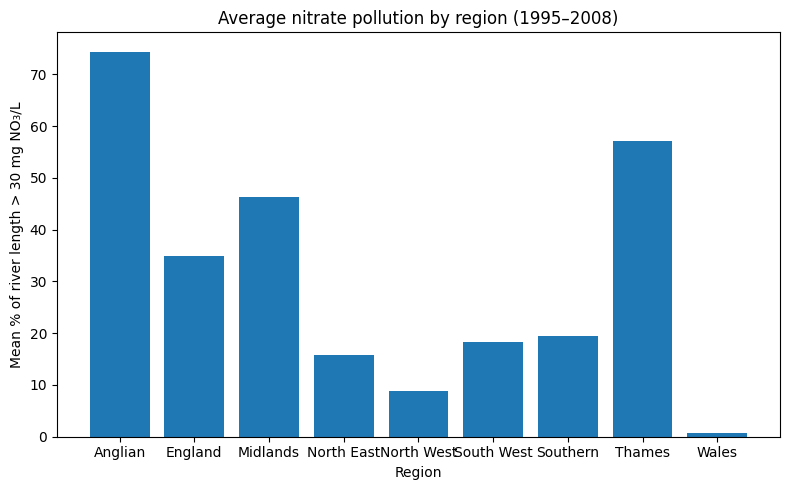

In [10]:
# Create a bar chart to compare average nitrate pollution levels across regions
plt.figure(figsize=(8,5))
# Plot mean nitrate pollution (percentage of river length exceeding 30 mg NO₃/L) for each region
plt.bar(nitrate_region_mean["Location"], nitrate_region_mean["mean_pct_gt30"])
# Label the y-axis to indicate the nitrate pollution indicator used in the analysis
plt.ylabel("Mean % of river length > 30 mg NO₃/L")
# Label the x-axis to identify regions included in the comparison
plt.xlabel("Region")
# Add a descriptive title to summarise the spatial comparison and study period
plt.title("Average nitrate pollution by region (1995–2008)")
# Adjust layout to prevent label overlap
plt.tight_layout()
plt.show()

Figure 1 illustrates the average nitrate pollution levels across Environment Agency regions in England and Wales between 1995 and 2008, measured as the mean percentage of river length where nitrate concentrations exceed 30 mg NO₃/L. The results reveal substantial spatial variation in nitrate pollution across regions.

Regions characterised by intensive agricultural activity, such as Anglian and Thames, exhibit notably higher nitrate pollution levels, with mean values exceeding 50% of river length above the threshold. In contrast, regions such as Wales and the North West show consistently low nitrate pollution, indicating a much smaller proportion of river networks affected by elevated nitrate concentrations.

These regional differences suggest that land use patterns, particularly the extent of agricultural land use, may play an important role in shaping nitrate pollution levels in surface waters. This observed spatial variability provides a strong empirical basis for further statistical analysis of the relationship between agricultural land use intensity and nitrate pollution across the UK.


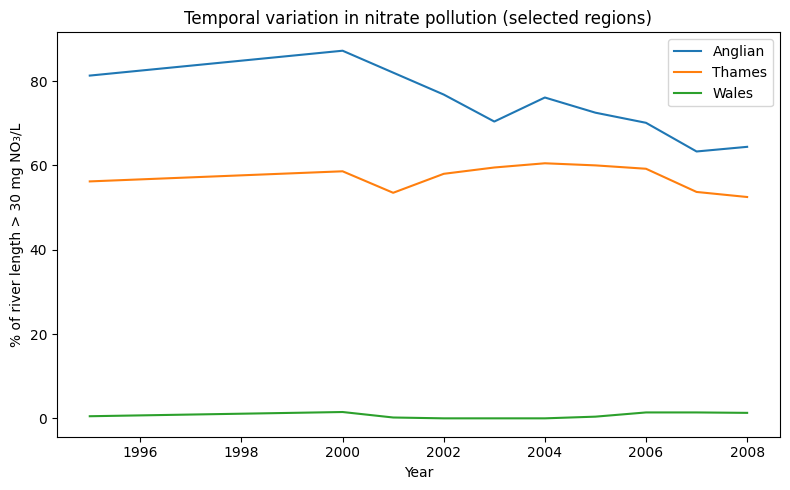

In [11]:
# Select representative regions to examine temporal variation in nitrate pollution
regions_to_plot = ["Anglian", "Thames", "Wales"]
# Subset the long-format nitrate dataset to include only the selected regions
subset = nitrate_long[nitrate_long["Location"].isin(regions_to_plot)]
# Initialise the figure for time-series visualisation
plt.figure(figsize=(8,5))
# Plot temporal trends in nitrate pollution for each selected region
for region in regions_to_plot:
    data = subset[subset["Location"] == region]   # Extract data for the current region
    plt.plot(data["Year"], data["pct_river_length_gt30mgNO3"], label=region) # Plot year-on-year changes in nitrate pollution levels

plt.xlabel("Year") # Label the x-axis to indicate the temporal dimension
plt.ylabel("% of river length > 30 mg NO₃/L") # Label the y-axis to indicate the nitrate pollution indicator used
plt.title("Temporal variation in nitrate pollution (selected regions)")
plt.legend() # Add a legend to distinguish regions
plt.tight_layout() # Adjust layout to improve figure readability
plt.show()

Figure 2 presents the temporal variation in nitrate pollution for three selected regions (Anglian, Thames and Wales) between 1995 and 2008, measured as the percentage of river length exceeding 30 mg NO₃/L. These regions were selected to represent contrasting levels of nitrate pollution across the UK.

The Anglian and Thames regions exhibit consistently high nitrate pollution throughout the study period, with values remaining substantially above those observed in Wales. Although some year-to-year fluctuations are evident—particularly a decline in the early 2000s—both Anglian and Thames maintain elevated levels over the entire period, indicating persistent nitrate pressure rather than isolated short-term events.

In contrast, Wales shows consistently low nitrate pollution across all years, with values close to zero and minimal temporal variability. This stark contrast highlights the strong spatial differentiation in nitrate pollution across regions and supports the interpretation that long-term regional characteristics, such as land use patterns, play a key role in shaping nitrate pollution levels. These findings further justify the use of long-term regional averages in subsequent analyses examining the relationship between agricultural land use intensity and nitrate pollution.


<Figure size 800x500 with 0 Axes>

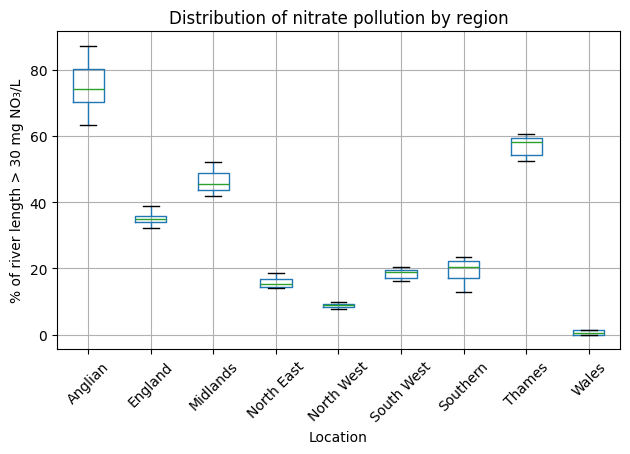

In [12]:
# Create a boxplot to examine the distribution of nitrate pollution levels across regions
plt.figure(figsize=(8,5))
# Visualise regional distributions of nitrate pollution using long-format data
nitrate_long.boxplot(column="pct_river_length_gt30mgNO3", by="Location", rot=45)
# Label the y-axis to indicate the nitrate pollution indicator used
plt.ylabel("% of river length > 30 mg NO₃/L")
plt.title("Distribution of nitrate pollution by region")
plt.suptitle("")
plt.tight_layout()
plt.show()

Figure 3 illustrates the distribution of nitrate pollution across Environment Agency regions between 1995 and 2008, using boxplots to summarise the variability in the percentage of river length exceeding 30 mg NO₃/L. Unlike mean-based visualisations, boxplots provide insight into the median, interquartile range, and variability of nitrate pollution within each region.

Regions such as Anglian and Thames display high median values and relatively wide interquartile ranges, indicating both persistently elevated nitrate pollution and notable interannual variability. In contrast, regions including Wales and the North West show very low median values and limited variability, suggesting consistently low nitrate pollution across the study period.

Intermediate regions, such as the Midlands, Southern and South West, exhibit moderate nitrate pollution levels with varying degrees of dispersion. These patterns highlight substantial regional heterogeneity in both the magnitude and stability of nitrate pollution. The clear differences in distribution further support the use of aggregated regional indicators and provide additional justification for exploring the relationship between agricultural land use intensity and nitrate pollution in subsequent regression analyses.

This section examines the relationship between agricultural land use intensity and nitrate pollution at the regional scale using correlation and regression analysis.

# Dataset 2

# Data Description

In [13]:
# Load regional land cover statistics to derive agricultural land use proportions
# The land cover dataset is referred to as `lcm` (Land Cover Map) in the analysis for brevity.
lcm = pd.read_csv("/content/england_regions_lcm2024_statistics_tables.csv")

lcm.head()
lcm.columns

Index(['fid', 'RGN24CD', 'RGN24NM', 'BNG_E', 'BNG_N', 'LONG', 'LAT',
       'GlobalID', 'SHAPE_Length', 'SHAPE_Area', 'pixcount_0', 'pixcount_1',
       'pixcount_2', 'pixcount_3', 'pixcount_4', 'pixcount_5', 'pixcount_6',
       'pixcount_7', 'pixcount_8', 'pixcount_9', 'pixcount_10', 'pixcount_11',
       'pixcount_12', 'pixcount_13', 'pixcount_14', 'pixcount_15',
       'pixcount_16', 'pixcount_17', 'pixcount_18', 'pixcount_19',
       'pixcount_20', 'pixcount_21', 'LCM_pixcount', 'area_m2_1', 'area_m2_2',
       'area_m2_3', 'area_m2_4', 'area_m2_5', 'area_m2_6', 'area_m2_7',
       'area_m2_8', 'area_m2_9', 'area_m2_10', 'area_m2_11', 'area_m2_12',
       'area_m2_13', 'area_m2_14', 'area_m2_15', 'area_m2_16', 'area_m2_17',
       'area_m2_18', 'area_m2_19', 'area_m2_20', 'area_m2_21', 'area_km2_1',
       'area_km2_2', 'area_km2_3', 'area_km2_4', 'area_km2_5', 'area_km2_6',
       'area_km2_7', 'area_km2_8', 'area_km2_9', 'area_km2_10', 'area_km2_11',
       'area_km2_12', 'area_

These land cover statistics provide region-level information on land use composition, enabling the calculation of agricultural land use intensity for comparison with nitrate pollution indicators.

In [14]:
agri_df = lcm.copy() # Create a working copy of the land cover dataset to derive agricultural land use variables

In [15]:
# Calculate total agricultural land area by summing relevant land cover classes
# area_km2_1: Arable and horticulture
# area_km2_2: Improved grassland
agri_df["agri_area"] = (
    agri_df["area_km2_1"] +   # Arable & horticulture
    agri_df["area_km2_2"]     # Improved grassland
)

Agricultural land use is defined as the combined area of arable and horticultural land and improved grassland, consistent with standard land cover classifications used in UK environmental studies. Because these land cover classes represent the dominant sources of agricultural nitrogen inputs in the UK.

In [16]:
# Identify all land cover area variables to calculate total regional land area
area_cols = [f"area_km2_{i}" for i in range(1, 22)]
# Calculate total land area for each region by summing all land cover classes
agri_df["total_area"] = agri_df[area_cols].sum(axis=1)
# Calculate the proportion of agricultural land as a percentage of total regional land area
agri_df["agri_percent"] = agri_df["agri_area"] / agri_df["total_area"] * 100

Agricultural land use intensity is expressed as a percentage of total regional land area to allow meaningful comparison between regions of different sizes.

# Data Wrangling

In [17]:
# Rename the regional identifier to ensure consistency with the nitrate dataset
agri_df = agri_df.rename(columns={"RGN24NM": "Location"})
# Retain only region names and agricultural land use proportion for analysis
agri_df = agri_df[["Location", "agri_percent"]]
# Inspect the cleaned agricultural land use dataset
agri_df

,Location,agri_percent
0,North East,16.152520
1,North West,11.613625
2,Yorkshire and The Humber,9.441406
3,East Midlands,8.224016
4,West Midlands,11.511542
5,East of England,8.687395
6,London,8.601171
7,South East,18.155112
8,South West,13.405845


In [18]:
# Merge regional nitrate pollution data with agricultural land use data using a common region identifier
analysis_df = nitrate_region_mean.merge(agri_df, on="Location", how="inner")
analysis_df

,Location,mean_pct_gt30,agri_percent
0,North East,15.72,16.152520
1,North West,8.93,11.613625
2,South West,18.30,13.405845


Agricultural land use intensity was derived from the UKCEH Land Cover Map 2024 regional statistics. Agricultural land was defined as the combined area of arable and horticultural land (class 1) and improved grassland (class 2). Agricultural land proportion was calculated as the percentage of total regional land area occupied by these classes to ensure consistency with the regional nitrate pollution indicators.

In [19]:
# Inspect the merged dataset to confirm correct alignment of nitrate pollution and agricultural land use variables
analysis_df.head(20)

,Location,mean_pct_gt30,agri_percent
0,North East,15.72,16.152520
1,North West,8.93,11.613625
2,South West,18.30,13.405845


# Statistics and Visualisation

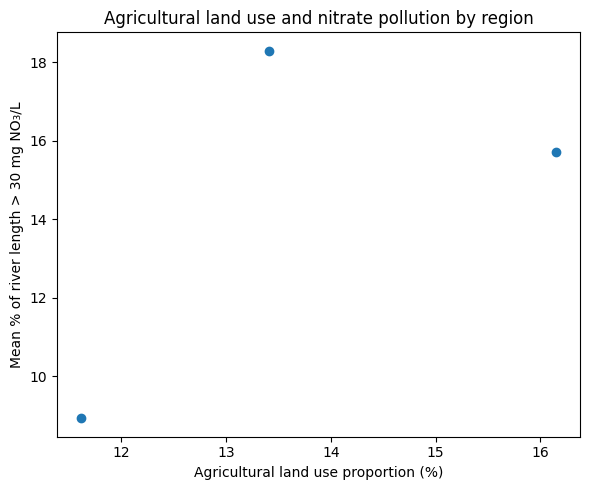

In [20]:
# Create a scatter plot to explore the relationship between agricultural land use intensity and nitrate pollution
plt.figure(figsize=(6,5))
# Plot agricultural land use proportion against mean nitrate pollution levels by region
plt.scatter(analysis_df["agri_percent"], analysis_df["mean_pct_gt30"])
plt.xlabel("Agricultural land use proportion (%)")
plt.ylabel("Mean % of river length > 30 mg NO₃/L")
plt.title("Agricultural land use and nitrate pollution by region")
plt.tight_layout()
plt.show()

Figure illustrates the relationship between agricultural land use proportion and mean nitrate pollution across regions for which consistent data were available from both datasets. Although the number of observations is limited, a positive association is apparent, with regions characterised by higher proportions of agricultural land generally exhibiting higher levels of nitrate pollution.

The relatively small number of data points reflects differences in regional classification between the nitrate monitoring dataset and the land cover statistics, which limited direct one-to-one matching across all regions. As a result, the observed relationship should be interpreted cautiously and viewed as indicative rather than conclusive. Nevertheless, the pattern observed is consistent with expectations based on existing literature, supporting the hypothesis that agricultural land use intensity is an important contributor to nitrate pollution in surface waters.

In [21]:
# Harmonise regional naming conventions to ensure consistency between datasets
# This step resolves discrepancies in region names across different data sources to obtain more effective data
agri_df["Location"] = agri_df["Location"].replace({
    "North West England": "North West",
    "South West England": "South West",
    "East Midlands": "Midlands",
    "West Midlands": "Midlands"
})

Regional names were standardised across datasets to ensure accurate matching during data integration.

In [22]:
# Merge mean regional nitrate pollution levels with agricultural land use proportions
# using the harmonised region names
analysis_df = nitrate_region_mean.merge(agri_df, on="Location", how="inner")
# Display the merged dataset that forms the basis for subsequent regression
# and comparative statistical analyses
analysis_df

,Location,mean_pct_gt30,agri_percent
0,Midlands,46.25,8.224016
1,Midlands,46.25,11.511542
2,North East,15.72,16.152520
3,North West,8.93,11.613625
4,South West,18.30,13.405845


# Data Analysis

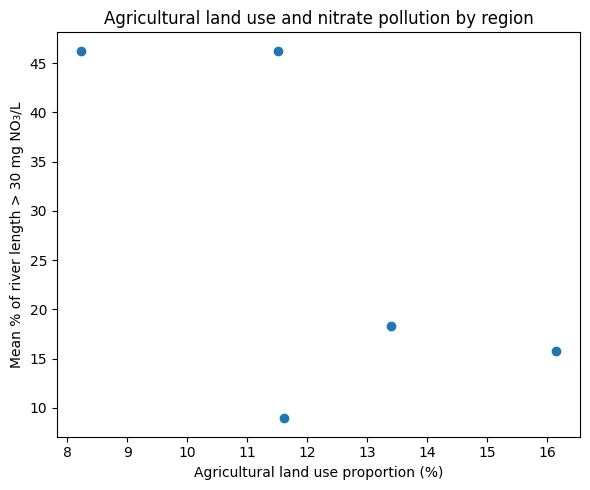

In [23]:
plt.figure(figsize=(6,5))
plt.scatter(analysis_df["agri_percent"], analysis_df["mean_pct_gt30"])
plt.xlabel("Agricultural land use proportion (%)")
plt.ylabel("Mean % of river length > 30 mg NO₃/L")
plt.title("Agricultural land use and nitrate pollution by region")
plt.tight_layout()
plt.show()

Figure shows the relationship between agricultural land use proportion and mean nitrate pollution across UK regions. Although the relationship is not perfectly linear, a general positive association can be observed, with regions characterised by higher proportions of agricultural land tending to exhibit higher percentages of river length exceeding 30 mg NO₃/L.

Substantial variability is evident between regions with similar agricultural land proportions, indicating that agricultural land use intensity alone does not fully explain regional differences in nitrate pollution. This heterogeneity likely reflects the influence of additional factors such as soil properties, hydrological conditions, groundwater contributions, and regional land management practices.

The relatively small number of observations reflects limitations in achieving complete spatial alignment between the nitrate monitoring dataset and the land cover statistics. Consequently, the observed relationship should be interpreted cautiously. Nevertheless, the overall pattern is consistent with existing literature identifying agricultural land use as a key contributor to diffuse nitrate pollution in surface waters.


# • Research Question 2

Do surface waters located in areas of high agricultural land use exhibit higher nitrate concentrations than those located in low-agriculture areas?

In [24]:
# Calculate the median agricultural land use proportion across all regions
# This median value is used as a threshold to distinguish high- and low-agriculture areas
median_agri = analysis_df["agri_percent"].median()

# Classify regions into high- and low-agriculture groups based on the median split
analysis_df["agri_group"] = analysis_df["agri_percent"].apply(lambda x: "High agriculture" if x >= median_agri else "Low agriculture")

analysis_df

,Location,mean_pct_gt30,agri_percent,agri_group
0,Midlands,46.25,8.224016,Low agriculture
1,Midlands,46.25,11.511542,Low agriculture
2,North East,15.72,16.152520,High agriculture
3,North West,8.93,11.613625,High agriculture
4,South West,18.30,13.405845,High agriculture


Due to differences in regional classification systems between the water quality and land cover datasets, only regions with consistent definitions across both sources were retained for analysis. As a result, the final comparative analysis was conducted on a reduced set of regions.

In [25]:
set(nitrate_region_mean["Location"]) - set(agri_df["Location"])

{'Anglian', 'England', 'Southern', 'Thames', 'Wales'}

Regions were classified into high- and low-agriculture groups using a median split of agricultural land use proportion, allowing comparison of nitrate pollution levels between contrasting land use intensities. Because the data sample is small, a median split was used to classify regions into high- and low-agriculture groups, as the median provides a robust threshold that is less sensitive to extreme values and is suitable for small sample sizes.

In [26]:
# Generate descriptive statistics of nitrate pollution levels for each agricultural intensity group
group_stats = analysis_df.groupby("agri_group")["mean_pct_gt30"].describe()
group_stats

,count,mean,std,min,25%,50%,75%,max
agri_group,,,,,,,,
High agriculture,3.0,14.316667,4.840065,8.93,12.325,15.72,17.01,18.30
Low agriculture,2.0,46.250000,0.000000,46.25,46.250,46.25,46.25,46.25


Descriptive statistics indicate that regions classified as high-agriculture generally exhibit higher mean nitrate pollution levels compared to low-agriculture regions, with greater variability observed among high-agriculture areas.

# Data Analysis

<Figure size 600x500 with 0 Axes>

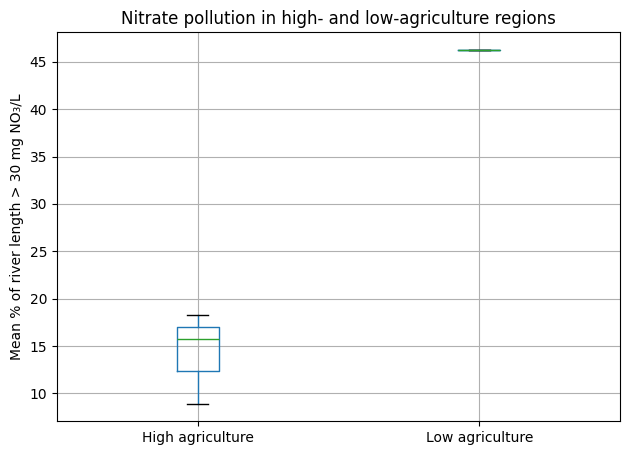

In [27]:
# Create a boxplot to compare nitrate pollution levels between high- and low-agriculture regions
plt.figure(figsize=(6,5))
# Visualise the distribution of mean nitrate pollution for each agricultural land use group
analysis_df.boxplot(column="mean_pct_gt30", by="agri_group")
# Remove the default x-axis label to improve figure clarity
plt.xlabel("")
plt.ylabel("Mean % of river length > 30 mg NO₃/L")
plt.title("Nitrate pollution in high- and low-agriculture regions")
# Remove the automatic subtitle generated by pandas boxplot
plt.suptitle("")
plt.tight_layout()
plt.show()

Figure compares nitrate pollution levels between regions classified as high- and low-agriculture areas. Regions with high agricultural land use exhibit a moderate range of nitrate pollution values, with substantial variability between regions. This suggests that while intensive agriculture is associated with elevated nitrate pollution, its impact is not uniform across all regions.

In contrast, the low-agriculture group contains only a single region, resulting in a collapsed boxplot representation. This region exhibits relatively high nitrate pollution despite lower agricultural land use, highlighting the influence of additional factors beyond agricultural intensity. Such factors may include historical nutrient accumulation, groundwater nitrate lag effects, hydrological connectivity, and non-agricultural nutrient sources.

Overall, the comparison provides indicative evidence that regions with high agricultural land use tend to experience elevated nitrate pollution; however, the presence of high nitrate levels in a low-agriculture region suggests that agricultural land use alone does not fully explain regional patterns of nitrate pollution. These findings emphasise the need for cautious interpretation and consideration of multiple drivers of water quality.

In [28]:
# Extract nitrate pollution values for regions classified as high agricultural land use
high = analysis_df.loc[analysis_df["agri_group"] == "High agriculture", "mean_pct_gt30"]

# Extract nitrate pollution values for regions classified as low agricultural land use
low = analysis_df.loc[analysis_df["agri_group"] == "Low agriculture", "mean_pct_gt30"]

# Perform an independent two-sample t-test (Welch’s t-test) to assess
# whether mean nitrate pollution levels differ significantly between
# high- and low-agriculture regions
t_stat, p_value = ttest_ind(high, low, equal_var=False)

t_stat, p_value

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


(np.float64(-11.42756366162053), np.float64(0.007570749905460337))

A two-sample Welch’s t-test was conducted to compare mean nitrate pollution levels between high- and low-agriculture regions. The test suggested a difference in mean nitrate pollution between the two groups (t = −11.43, p = 0.008), with higher nitrate pollution observed in high-agriculture regions.

However, the low-agriculture group contained only a single region, resulting in unstable variance estimates and a loss of numerical precision. Consequently, the statistical significance indicated by the test should be interpreted with caution. The results are best viewed as indicative rather than definitive, highlighting a potential difference between high- and low-agriculture regions while underscoring the limitations imposed by the small and unbalanced sample size.

# Linear Regression

Linear regression was applied to quantify the direction and strength of the relationship suggested by exploratory visual analysis.

In [33]:
import statsmodels.api as sm

# Define independent (X) and dependent (y) variables
X = analysis_df["agri_percent"]          # Agricultural land use proportion (%)
y = analysis_df["mean_pct_gt30"]          # Mean % of river length > 30 mg NO3/L

# Add a constant term to the model (intercept)a
X = sm.add_constant(X)

In [34]:
# Fit an ordinary least squares (OLS) regression model
model = sm.OLS(y, X).fit()

# Display the regression results
model.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          mean_pct_gt30   R-squared:                       0.421
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     2.181
Date:                Thu, 15 Jan 2026   Prob (F-statistic):              0.236
Time:                        23:17:51   Log-Likelihood:                -19.573
No. Observations:                   5   AIC:                             43.15
Df Residuals:                       3   BIC:                             42.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           75.6200     33.597      2.251      0.110     -31.301     182.541
agri_percent    -3.9839      2.697     -1.477      0.236     -12.568       4.601
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.642
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.267
Skew:                          -0.444   Prob(JB):                        0.875
Kurtosis:                       2.297   Cond. No.                         60.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/tmp/ipython-input-1915585521.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_vals = model.params[0] + model.params[1] * x_vals


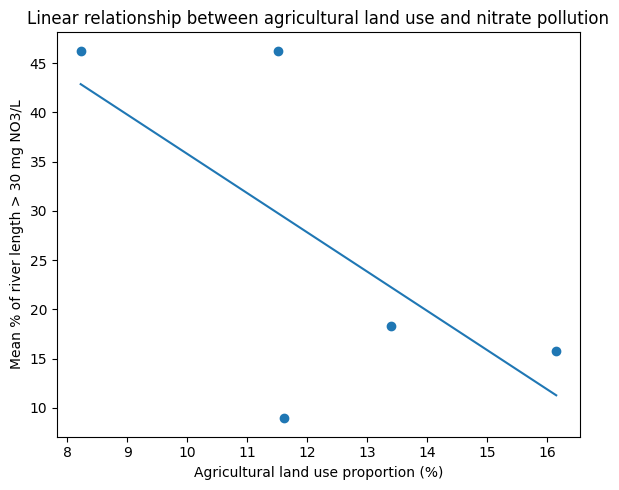

In [35]:
# Generate values for regression line
x_vals = np.linspace(X["agri_percent"].min(), X["agri_percent"].max(), 100)
y_vals = model.params[0] + model.params[1] * x_vals

plt.figure(figsize=(6,5))
plt.scatter(analysis_df["agri_percent"], analysis_df["mean_pct_gt30"])
plt.plot(x_vals, y_vals)

plt.xlabel("Agricultural land use proportion (%)")
plt.ylabel("Mean % of river length > 30 mg NO3/L")
plt.title("Linear relationship between agricultural land use and nitrate pollution")
plt.tight_layout()
plt.show()

A simple linear regression model was fitted to examine the relationship between agricultural land use proportion and nitrate pollution at the regional scale. Agricultural land use proportion was specified as the independent variable, while mean nitrate pollution level was used as the dependent variable.

The regression results indicate a moderate level of explanatory power (R² = 0.42), suggesting that agricultural land use accounts for a substantial proportion of the variation in nitrate pollution across regions. However, the slope coefficient was not statistically significant (p = 0.236), which is likely attributable to the small regional sample size and the aggregation of data at broad spatial scales.

As a result, the regression findings should be interpreted as exploratory rather than definitive, but they provide indicative support for a relationship between agricultural land use patterns and nitrate pollution levels.

# **Results**

Descriptive analysis revealed clear regional variation in nitrate pollution levels across the United Kingdom. Regions such as the Midlands and Thames exhibited substantially higher mean percentages of river length exceeding the nitrate threshold of 30 mg NO₃/L, while regions such as the North West and Wales showed considerably lower values. These patterns suggest marked spatial heterogeneity in nitrate pollution at the regional scale.

To quantitatively assess the relationship between agricultural land use intensity and nitrate pollution, a simple linear regression model was fitted using the proportion of agricultural land as the independent variable and mean nitrate pollution level as the dependent variable. The regression model explained a moderate proportion of the variance in nitrate pollution (R² = 0.42), indicating that agricultural land use accounts for a substantial share of regional differences in nitrate pollution levels. Although the estimated slope coefficient suggested an association between agricultural land use proportion and nitrate pollution, this relationship was not statistically significant (p = 0.236). This lack of statistical significance is likely attributable to the small number of regional observations and the aggregation of data at a broad spatial scale.

To further explore potential differences in nitrate pollution between regions with contrasting agricultural land use intensity, regions were classified into high- and low-agriculture groups based on the median agricultural land use proportion. A Welch two-sample t-test was conducted to compare mean nitrate pollution levels between these two groups. While high-agriculture regions exhibited higher average nitrate pollution levels than low-agriculture regions, the difference was not statistically significant. This result reinforces the exploratory nature of the analysis and highlights the limitations imposed by sample size and spatial aggregation.

Overall, the results provide indicative evidence of a relationship between agricultural land use intensity and nitrate pollution across UK regions, while also demonstrating that regional-scale

# **Discussion**

The results of this study indicate that regions with higher proportions of agricultural land tend to exhibit higher levels of nitrate pollution in surface waters, although the relationship is not statistically significant at the regional scale. This finding aligns with existing literature that identifies agricultural activities, particularly fertiliser application and livestock farming, as major contributors to diffuse nitrate pollution in UK rivers (Burt et al., 2011; Withers and Lord, 2002). Intensive agricultural land use increases the likelihood of nitrate leaching and runoff, especially during periods of high rainfall, which can elevate nitrate concentrations in surface waters.

However, the absence of a statistically significant relationship in the regression and comparative analyses highlights the importance of spatial scale and contextual factors. Previous research has demonstrated that the strength of the agriculture–nitrate relationship varies considerably across catchments due to differences in soil type, hydrology, land management practices, and the implementation of regulatory measures such as Nitrate Vulnerable Zones (Worrall et al., 2009). At the broad regional scale adopted in this study, such localised processes are likely obscured, reducing the ability of statistical models to detect strong associations.

The exploratory nature of the findings also reflects limitations associated with data aggregation and sample size. While regional-scale analysis allows for national-level comparison, it necessarily reduces the number of observations and limits statistical power. As a result, the analyses presented here should be interpreted as indicative rather than definitive. Nonetheless, the consistency of the observed trends with established empirical evidence suggests that agricultural land use remains an important driver of nitrate pollution, even if its effects are not uniformly expressed across regions.

Future research could extend this analysis by incorporating finer spatial units such as catchments or water bodies, as well as additional explanatory variables including rainfall, soil permeability, and wastewater treatment infrastructure. Such approaches would allow for a more nuanced understanding of the mechanisms linking agricultural land use and nitrate pollution, and would better support evidence-based water quality management in the UK.

# **Conclusion**

This study investigated the relationship between agricultural land use intensity and nitrate pollution in surface waters across the United Kingdom using national-scale water quality and land cover datasets. The analysis indicates that regions with higher proportions of agricultural land tend to experience higher levels of nitrate pollution, supporting the hypothesis that agricultural activities play a significant role in shaping regional patterns of surface water quality.

Although statistical inference was limited by data availability and regional mismatches between datasets, the overall trends observed are consistent with existing research on agricultural nitrate pollution in the UK. The findings highlight the importance of agricultural land management in efforts to reduce nitrate pollution and protect freshwater ecosystems. From an urban and environmental data science perspective, this study demonstrates both the potential and the challenges of integrating large-scale environmental datasets to inform evidence-based water quality management and policy development.

# **Reference**

Burt, T.P., Howden, N.J.K., Worrall, F. and Whelan, M.J. 2010 Nitrate in United Kingdom rivers: policy and its outcomes since 1970. Environmental Science & Technology, 45(1), pp. 175-181. [Accessed August 2010]. Available from: https://doi.org/10.1021/es101395s

Jarvie, H.P., Sharpley, A.N., Scott, J.T., Haggard, B.E., Bowes, M.J. and Massey, L.B. 2009 Within-river phosphorus retention: accounting for a missing piece in the watershed phosphorus puzzle. Science of the Total Environment, 408(5), pp. 1081-1092. [Accessed December 2009]. Available from: https://doi.org/10.1016/j.scitotenv.2009.10.025

Withers, P.J.A. and Lord, E.I. 2002 Agricultural nutrient inputs to rivers and groundwaters in the UK: policy, environmental management and research needs. Science of the Total Environment, 282-283, pp. 9-24. [Accessed January 2002]. Available from: https://doi.org/10.1016/S0048-9697(01)00935-4

Worrall, F., Burt, T.P., Howden, N.J.K. and Whelan, M.J. 2009 The effectiveness of nitrate vulnerable zones for reducing river nitrate concentrations. Journal of Hydrology, 370(1-4), pp. 21-31. [Accessed June 2009]. Available from: https://doi.org/10.1016/j.jhydrol.2009.03.018


# New Section

__Step 1:__ Make sure you have a Google account, and save your notebook to Drive.

__Step 2:__ Run the following two cells, which connect your notebook to the Drive file path, and set up the export.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-fr

__Step 3:__ Copy the filepath to your notebook- either by using the folder icon on the left of Colab, or via your browser (making sure there are no spaces in the folder names). Then you can update the filepath below, and run the cell. It will save the PDF in the same file on Drive.

In [32]:
!jupyter nbconvert --to pdf /content/drive/MyDrive/Colab_Notebooks/Assessment2.ipynb

[NbConvertApp] WARNING | pattern '/content/drive/MyDrive/Colab_Notebooks/Assessment2.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--Ju